In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required packages
!pip install -q albumentations timm scikit-learn opencv-python-headless

print("✅ Setup completed!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup completed!


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from torch.cuda.amp import GradScaler, autocast
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from timm.data.mixup import Mixup
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("✅ Libraries imported and seed set!")


✅ Libraries imported and seed set!


In [ ]:
CONFIG = {
    # Paths
    'DATA_DIR': '/content/drive/MyDrive/archive/colored_images',
    'LABELS_CSV': '/content/drive/MyDrive/archive/train.csv',
    'MODELS_DIR': '/content/drive/MyDrive/models',

    # Data
    'IMG_SIZE': 224,
    'NUM_CLASSES': 5,
    'BATCH_SIZE': 32,
    'NUM_WORKERS': 2,

    # Model
    'MODEL_NAME': 'tf_efficientnetv2_s',
    'PRETRAINED': True,
    'DROPOUT': 0.3,

    # Training - Phase 1 (Frozen Backbone)
    'EPOCHS_PHASE1': 8,
    'LR_PHASE1': 1e-3,

    # Training - Phase 2 (Fine-tuning)
    'EPOCHS_PHASE2': 15,
    'LR_PHASE2': 1e-4,

    # Optimization
    'WEIGHT_DECAY': 1e-4,
    'LR_SCHEDULER': 'cosine',
    'PLATEAU_FACTOR': 0.5,
    'PLATEAU_PATIENCE': 3,

    # Regularization
    'USE_MIXUP': True,
    'MIXUP_ALPHA': 0.2,
    'USE_CUTMIX': False,
    'CUTMIX_ALPHA': 1.0,
    'LABEL_SMOOTHING': 0.1,

    # Augmentation
    'USE_CLAHE': True,
    'CLAHE_CLIP_LIMIT': 2.0,
    'CLAHE_PROB': 0.5,

    # Training
    'USE_AMP': True,
    'GRADIENT_CLIP': 1.0,
    'EARLY_STOPPING_PATIENCE': 5,
    'MONITOR_METRIC': 'val_kappa',

    # Loss
    'LOSS_TYPE': 'focal',  # 'ce' or 'focal'
    'FOCAL_ALPHA': 0.25,
    'FOCAL_GAMMA': 2.0,

    # Other
    'SEED': 42,
    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create directories
os.makedirs(CONFIG['MODELS_DIR'], exist_ok=True)

print("✅ Configuration set!")
print(f"Device: {CONFIG['DEVICE']}")


✅ Configuration set!
Device: cuda


In [ ]:
def load_and_prepare_data(config):
    print("📊 Loading dataset...")
    df = pd.read_csv(config['LABELS_CSV'])
    print(f"Total samples: {len(df)}")

    # Map diagnosis to folder names
    diagnosis_to_folder = {
        0: 'No_DR',
        1: 'Mild',
        2: 'Moderate',
        3: 'Severe',
        4: 'Proliferate_DR'
    }

    def get_image_path(row):
        folder = diagnosis_to_folder[row['diagnosis']]
        base_path = os.path.join(config['DATA_DIR'], folder)
        for ext in ['.png', '.jpg', '.jpeg']:
            image_path = os.path.join(base_path, row['id_code'] + ext)
            if os.path.exists(image_path):
                return image_path
        return None

    df['image_path'] = df.apply(get_image_path, axis=1)

    missing_count = df['image_path'].isna().sum()
    print(f"⚠️ Warning: {missing_count} images not found, removing from dataset")
    df = df.dropna(subset=['image_path']).reset_index(drop=True)

    print(f"Verified samples: {len(df)}")
    print("\n📈 Class distribution:")
    print(df['diagnosis'].value_counts().sort_index())

    if len(df) == 0:
        raise RuntimeError("No images found! Please check image folder paths.")

    return df

# Load data
df = load_and_prepare_data(CONFIG)


📊 Loading dataset...
Total samples: 3662
⚠️ Warning: 0 images not found, removing from dataset
Verified samples: 3662

📈 Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [ ]:
def split_data(df, config):
    # Train 70%, Temp 30%
    train_df, temp_df = train_test_split(
        df,
        test_size=0.3,
        stratify=df['diagnosis'],
        random_state=config['SEED']
    )

    # Validation 15%, Test 15%
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        stratify=temp_df['diagnosis'],
        random_state=config['SEED']
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    print(f"Train samples: {len(train_df)}")
    print(f"Validation samples: {len(val_df)}")
    print(f"Test samples: {len(test_df)}")

    return train_df, val_df, test_df

train_df, val_df, test_df = split_data(df, CONFIG)


Train samples: 2563
Validation samples: 549
Test samples: 550


In [ ]:
class CLAHETransform:
    """Apply CLAHE enhancement for medical images"""
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img, **kwargs):
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
        l = clahe.apply(l)
        lab = cv2.merge([l, a, b])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def get_train_transforms(config):
    height, width = config['IMG_SIZE'], config['IMG_SIZE']
    transforms_list = []

    if config['USE_CLAHE']:
        transforms_list.append(
            A.Lambda(
                image=CLAHETransform(clip_limit=config['CLAHE_CLIP_LIMIT']),
                p=config['CLAHE_PROB']
            )
        )

    transforms_list.extend([
        A.RandomResizedCrop(size=(height, width), scale=(0.9, 1.0), p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

    return A.Compose(transforms_list)

def get_val_transforms(config):
    height, width = config['IMG_SIZE'], config['IMG_SIZE']
    return A.Compose([
        A.Resize(height=height, width=width),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

print("✅ Augmentation pipelines created")


✅ Augmentation pipelines created


In [ ]:
class DRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['image_path']
        label = row['diagnosis']

        # Load image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, label

print("✅ Dataset class created")


✅ Dataset class created


In [ ]:
train_dataset = DRDataset(train_df, transform=get_train_transforms(CONFIG))
val_dataset = DRDataset(val_df, transform=get_val_transforms(CONFIG))
test_dataset = DRDataset(test_df, transform=get_val_transforms(CONFIG))

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=True,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=True
)

print(f"✅ Data loaders created")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


✅ Data loaders created
Train batches: 81
Val batches: 18
Test batches: 18


In [ ]:
class DRModel(nn.Module):
    def __init__(self, model_name, num_classes, pretrained=True, dropout=0.3):
        super(DRModel, self).__init__()

        # Load pretrained backbone
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)

        # Get number of features
        n_features = self.backbone.num_features

        # Custom classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(n_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.classifier(features)
        return out

# Initialize model
device = torch.device(CONFIG['DEVICE'])
model = DRModel(
    model_name=CONFIG['MODEL_NAME'],
    num_classes=CONFIG['NUM_CLASSES'],
    pretrained=CONFIG['PRETRAINED'],
    dropout=CONFIG['DROPOUT']
).to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Model created: {CONFIG['MODEL_NAME']}")
print(f"Total parameters: {count_parameters(model):,}")


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

✅ Model created: tf_efficientnetv2_s
Total parameters: 20,836,949


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Choose loss function
if CONFIG['LOSS_TYPE'] == 'focal':
    loss_fn = FocalLoss(alpha=CONFIG['FOCAL_ALPHA'], gamma=CONFIG['FOCAL_GAMMA'])
    print("✅ Using Focal Loss")
else:
    # Calculate class weights for imbalanced dataset
    class_counts = train_df['diagnosis'].value_counts().sort_index().values
    class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
    class_weights = class_weights / class_weights.sum() * len(class_weights)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))
    print("✅ Using Weighted CrossEntropy Loss")


✅ Using Focal Loss


In [ ]:
if CONFIG['USE_MIXUP']:
    mixup_fn = Mixup(
        mixup_alpha=CONFIG['MIXUP_ALPHA'],
        cutmix_alpha=0.0 if not CONFIG['USE_CUTMIX'] else CONFIG['CUTMIX_ALPHA'],
        prob=0.5,
        switch_prob=0.5,
        mode='batch',
        label_smoothing=CONFIG['LABEL_SMOOTHING'],
        num_classes=CONFIG['NUM_CLASSES']
    )
    print(f"✅ MixUp enabled (alpha={CONFIG['MIXUP_ALPHA']})")
else:
    mixup_fn = None
    print("⚠️ MixUp disabled")


✅ MixUp enabled (alpha=0.2)


In [ ]:
def train_epoch(model, loader, optimizer, loss_fn, mixup_fn, device, scaler, config):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        # Apply MixUp
        if mixup_fn is not None:
            images, labels_mixed = mixup_fn(images, labels)

        optimizer.zero_grad()

        # Mixed precision training
        if config['USE_AMP']:
            with autocast():
                outputs = model(images)
                if mixup_fn is not None:
                    loss = loss_fn(outputs, labels_mixed)
                else:
                    loss = loss_fn(outputs, labels)

            scaler.scale(loss).backward()

            if config['GRADIENT_CLIP'] > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), config['GRADIENT_CLIP'])

            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            if mixup_fn is not None:
                loss = loss_fn(outputs, labels_mixed)
            else:
                loss = loss_fn(outputs, labels)

            loss.backward()

            if config['GRADIENT_CLIP'] > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), config['GRADIENT_CLIP'])

            optimizer.step()

        running_loss += loss.item()

        # For metrics (only when not using MixUp for this batch or after training)
        if mixup_fn is None:
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / len(loader)

    # Calculate metrics
    if len(all_labels) > 0:
        accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
        f1_macro = f1_score(all_labels, all_preds, average='macro')
        kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    else:
        accuracy = f1_macro = kappa = 0.0

    return {
        'loss': epoch_loss,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'kappa': kappa
    }

def validate(model, loader, loss_fn, device, config):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images = images.to(device)
            labels = labels.to(device)

            if config['USE_AMP']:
                with autocast():
                    outputs = model(images)
                    loss = loss_fn(outputs, labels)
            else:
                outputs = model(images)
                loss = loss_fn(outputs, labels)

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

    return {
        'loss': epoch_loss,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'kappa': kappa
    }

print("✅ Training and validation functions ready")


✅ Training and validation functions ready


In [ ]:
print("\n" + "="*80)
print("PHASE 1: TRAINING WITH FROZEN BACKBONE")
print("="*80)

# Freeze backbone
for param in model.backbone.parameters():
    param.requires_grad = False

trainable_params_phase1 = count_parameters(model)
print(f"Trainable parameters: {trainable_params_phase1:,}")

# Optimizer and scheduler
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG['LR_PHASE1'],
    weight_decay=CONFIG['WEIGHT_DECAY']
)

if CONFIG['LR_SCHEDULER'] == 'cosine':
    scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['EPOCHS_PHASE1'])
else:
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=CONFIG['PLATEAU_FACTOR'],
        patience=CONFIG['PLATEAU_PATIENCE'],
        verbose=True
    )

scaler = GradScaler() if CONFIG['USE_AMP'] else None

history_phase1 = {
    'train_loss': [], 'train_acc': [], 'train_f1': [], 'train_kappa': [],
    'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_kappa': []
}

best_val_metric = -np.inf
patience_counter = 0

for epoch in range(CONFIG['EPOCHS_PHASE1']):
    print(f"\nEpoch [{epoch+1}/{CONFIG['EPOCHS_PHASE1']}]")

    train_metrics = train_epoch(model, train_loader, optimizer, loss_fn, mixup_fn, device, scaler, CONFIG)
    val_metrics = validate(model, val_loader, loss_fn, device, CONFIG)

    history_phase1['train_loss'].append(train_metrics['loss'])
    history_phase1['train_acc'].append(train_metrics['accuracy'])
    history_phase1['train_f1'].append(train_metrics['f1_macro'])
    history_phase1['train_kappa'].append(train_metrics['kappa'])

    history_phase1['val_loss'].append(val_metrics['loss'])
    history_phase1['val_acc'].append(val_metrics['accuracy'])
    history_phase1['val_f1'].append(val_metrics['f1_macro'])
    history_phase1['val_kappa'].append(val_metrics['kappa'])

    print(
        f"Train - Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, "
        f"F1: {train_metrics['f1_macro']:.4f}, Kappa: {train_metrics['kappa']:.4f}"
    )
    print(
        f"Val   - Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, "
        f"F1: {val_metrics['f1_macro']:.4f}, Kappa: {val_metrics['kappa']:.4f}"
    )

    monitor_key = CONFIG['MONITOR_METRIC'].replace('val_', '')
    current_metric = val_metrics[monitor_key]

    if current_metric > best_val_metric:
        best_val_metric = current_metric
        patience_counter = 0
        torch.save(model.state_dict(), f"{CONFIG['MODELS_DIR']}/best_model_phase1.pt")
        print(f"✅ Best model saved (metric: {current_metric:.4f})")
    else:
        patience_counter += 1

    if CONFIG['LR_SCHEDULER'] == 'cosine':
        scheduler.step()
    else:
        scheduler.step(current_metric)

    if patience_counter >= CONFIG['EARLY_STOPPING_PATIENCE']:
        print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
        break

print("\n✅ Phase 1 completed!")
model.load_state_dict(torch.load(f"{CONFIG['MODELS_DIR']}/best_model_phase1.pt"))
print("✅ Best model loaded from Phase 1")



PHASE 1: TRAINING WITH FROZEN BACKBONE
Trainable parameters: 659,461

Epoch [1/8]


Training:  99%|█████████▉| 80/81 [15:55<00:11, 11.94s/it, loss=0.135]


AssertionError: Batch size should be even when using this

In [ ]:
# Update DataLoaders before Step 13 training

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=True,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=True,
    drop_last=True  # Important: this fixes Mixup batch size error
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=True,
    drop_last=False  # Keep val and test full
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=True,
    drop_last=False
)

print(f"✅ Updated DataLoaders with drop_last for train_loader")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


✅ Updated DataLoaders with drop_last for train_loader
Train batches: 80, Val batches: 18, Test batches: 18


In [ ]:
print("\n" + "="*80)
print("PHASE 1: TRAINING WITH FROZEN BACKBONE")
print("="*80)

# Freeze backbone
for param in model.backbone.parameters():
    param.requires_grad = False

trainable_params_phase1 = count_parameters(model)
print(f"Trainable parameters: {trainable_params_phase1:,}")

# Optimizer and scheduler
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG['LR_PHASE1'],
    weight_decay=CONFIG['WEIGHT_DECAY']
)

if CONFIG['LR_SCHEDULER'] == 'cosine':
    scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['EPOCHS_PHASE1'])
else:
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=CONFIG['PLATEAU_FACTOR'],
        patience=CONFIG['PLATEAU_PATIENCE'],
        verbose=True
    )

scaler = GradScaler() if CONFIG['USE_AMP'] else None

history_phase1 = {
    'train_loss': [], 'train_acc': [], 'train_f1': [], 'train_kappa': [],
    'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_kappa': []
}

best_val_metric = -np.inf
patience_counter = 0

for epoch in range(CONFIG['EPOCHS_PHASE1']):
    print(f"\nEpoch [{epoch+1}/{CONFIG['EPOCHS_PHASE1']}]")

    train_metrics = train_epoch(model, train_loader, optimizer, loss_fn, mixup_fn, device, scaler, CONFIG)
    val_metrics = validate(model, val_loader, loss_fn, device, CONFIG)

    history_phase1['train_loss'].append(train_metrics['loss'])
    history_phase1['train_acc'].append(train_metrics['accuracy'])
    history_phase1['train_f1'].append(train_metrics['f1_macro'])
    history_phase1['train_kappa'].append(train_metrics['kappa'])

    history_phase1['val_loss'].append(val_metrics['loss'])
    history_phase1['val_acc'].append(val_metrics['accuracy'])
    history_phase1['val_f1'].append(val_metrics['f1_macro'])
    history_phase1['val_kappa'].append(val_metrics['kappa'])

    print(
        f"Train - Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, "
        f"F1: {train_metrics['f1_macro']:.4f}, Kappa: {train_metrics['kappa']:.4f}"
    )
    print(
        f"Val   - Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, "
        f"F1: {val_metrics['f1_macro']:.4f}, Kappa: {val_metrics['kappa']:.4f}"
    )

    monitor_key = CONFIG['MONITOR_METRIC'].replace('val_', '')
    current_metric = val_metrics[monitor_key]

    if current_metric > best_val_metric:
        best_val_metric = current_metric
        patience_counter = 0
        torch.save(model.state_dict(), f"{CONFIG['MODELS_DIR']}/best_model_phase1.pt")
        print(f"✅ Best model saved (metric: {current_metric:.4f})")
    else:
        patience_counter += 1

    if CONFIG['LR_SCHEDULER'] == 'cosine':
        scheduler.step()
    else:
        scheduler.step(current_metric)

    if patience_counter >= CONFIG['EARLY_STOPPING_PATIENCE']:
        print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
        break

print("\n✅ Phase 1 completed!")
model.load_state_dict(torch.load(f"{CONFIG['MODELS_DIR']}/best_model_phase1.pt"))
print("✅ Best model loaded from Phase 1")



PHASE 1: TRAINING WITH FROZEN BACKBONE
Trainable parameters: 659,461

Epoch [1/8]


Validation: 100%|██████████| 18/18 [03:45<00:00, 12.53s/it]


Train - Loss: 0.1254, Acc: 0.0000, F1: 0.0000, Kappa: 0.0000
Val   - Loss: 0.0873, Acc: 0.7523, F1: 0.4660, Kappa: 0.7609
✅ Best model saved (metric: 0.7609)

Epoch [2/8]


Validation: 100%|██████████| 18/18 [00:03<00:00,  4.72it/s]


Train - Loss: 0.1218, Acc: 0.0000, F1: 0.0000, Kappa: 0.0000
Val   - Loss: 0.0854, Acc: 0.7632, F1: 0.4654, Kappa: 0.7771
✅ Best model saved (metric: 0.7771)

Epoch [3/8]


...

Train - Loss: 0.1116, Acc: 0.0000, F1: 0.0000, Kappa: 0.0000
Val   - Loss: 0.0780, Acc: 0.7668, F1: 0.4717, Kappa: 0.8020
✅ Best model saved (metric: 0.8020)

Epoch [7/8]


Validation: 100%|██████████| 18/18 [00:03<00:00,  4.68it/s]


Train - Loss: 0.1115, Acc: 0.0000, F1: 0.0000, Kappa: 0.0000
Val   - Loss: 0.0773, Acc: 0.7687, F1: 0.4972, Kappa: 0.8024
✅ Best model saved (metric: 0.8024)

Epoch [8/8]


Validation: 100%|██████████| 18/18 [00:04<00:00,  4.39it/s]


Train - Loss: 0.1064, Acc: 0.0000, F1: 0.0000, Kappa: 0.0000
Val   - Loss: 0.0761, Acc: 0.7705, F1: 0.5060, Kappa: 0.8128
✅ Best model saved (metric: 0.8128)

✅ Phase 1 completed!
✅ Best model loaded from Phase 1


In [ ]:
print("\n" + "="*80)
print("PHASE 2: FINE-TUNING ENTIRE MODEL")
print("="*80)

# Unfreeze all parameters
for param in model.parameters():
    param.requires_grad = True

trainable_params_phase2 = count_parameters(model)
print(f"Trainable parameters: {trainable_params_phase2:,}")

# New optimizer with lower learning rate
optimizer = AdamW(
    model.parameters(),
    lr=CONFIG['LR_PHASE2'],
    weight_decay=CONFIG['WEIGHT_DECAY']
)

if CONFIG['LR_SCHEDULER'] == 'cosine':
    scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['EPOCHS_PHASE2'])
else:
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=CONFIG['PLATEAU_FACTOR'],
        patience=CONFIG['PLATEAU_PATIENCE'],
        verbose=True
    )

scaler = GradScaler() if CONFIG['USE_AMP'] else None

history_phase2 = {
    'train_loss': [], 'train_acc': [], 'train_f1': [], 'train_kappa': [],
    'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_kappa': []
}

best_val_metric = -np.inf
patience_counter = 0

for epoch in range(CONFIG['EPOCHS_PHASE2']):
    print(f"\nEpoch [{epoch+1}/{CONFIG['EPOCHS_PHASE2']}]")

    train_metrics = train_epoch(model, train_loader, optimizer, loss_fn, mixup_fn, device, scaler, CONFIG)
    val_metrics = validate(model, val_loader, loss_fn, device, CONFIG)

    history_phase2['train_loss'].append(train_metrics['loss'])
    history_phase2['train_acc'].append(train_metrics['accuracy'])
    history_phase2['train_f1'].append(train_metrics['f1_macro'])
    history_phase2['train_kappa'].append(train_metrics['kappa'])

    history_phase2['val_loss'].append(val_metrics['loss'])
    history_phase2['val_acc'].append(val_metrics['accuracy'])
    history_phase2['val_f1'].append(val_metrics['f1_macro'])
    history_phase2['val_kappa'].append(val_metrics['kappa'])

    print(
        f"Train - Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, "
        f"F1: {train_metrics['f1_macro']:.4f}, Kappa: {train_metrics['kappa']:.4f}"
    )
    print(
        f"Val   - Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, "
        f"F1: {val_metrics['f1_macro']:.4f}, Kappa: {val_metrics['kappa']:.4f}"
    )

    monitor_key = CONFIG['MONITOR_METRIC'].replace('val_', '')
    current_metric = val_metrics[monitor_key]

    if current_metric > best_val_metric:
        best_val_metric = current_metric
        patience_counter = 0
        torch.save(model.state_dict(), f"{CONFIG['MODELS_DIR']}/best_model_phase2.pt")
        print(f"✅ Best model saved (metric: {current_metric:.4f})")
    else:
        patience_counter += 1

    if CONFIG['LR_SCHEDULER'] == 'cosine':
        scheduler.step()
    else:
        scheduler.step(current_metric)

    if patience_counter >= CONFIG['EARLY_STOPPING_PATIENCE']:
        print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
        break

print("\n✅ Phase 2 completed!")
model.load_state_dict(torch.load(f"{CONFIG['MODELS_DIR']}/best_model_phase2.pt"))
print("✅ Best model loaded from Phase 2")



PHASE 2: FINE-TUNING ENTIRE MODEL
Trainable parameters: 20,836,949

Epoch [1/15]


Validation: 100%|██████████| 18/18 [00:03<00:00,  4.63it/s]


Train - Loss: 0.1057, Acc: 0.0000, F1: 0.0000, Kappa: 0.0000
Val   - Loss: 0.0681, Acc: 0.8069, F1: 0.6236, Kappa: 0.8492
✅ Best model saved (metric: 0.8492)

Epoch [2/15]


Validation: 100%|██████████| 18/18 [00:04<00:00,  4.33it/s]


Train - Loss: 0.0930, Acc: 0.0000, F1: 0.0000, Kappa: 0.0000
Val   - Loss: 0.0621, Acc: 0.8015, F1: 0.6117, Kappa: 0.8646
✅ Best model saved (metric: 0.8646)

Epoch [3/15]


...

Train - Loss: 0.0457, Acc: 0.0000, F1: 0.0000, Kappa: 0.0000
Val   - Loss: 0.0647, Acc: 0.8270, F1: 0.6914, Kappa: 0.8912
✅ Best model saved (metric: 0.8912)

Epoch [14/15]


Validation: 100%|██████████| 18/18 [00:04<00:00,  3.70it/s]


Train - Loss: 0.0491, Acc: 0.0000, F1: 0.0000, Kappa: 0.0000
Val   - Loss: 0.0659, Acc: 0.8270, F1: 0.6912, Kappa: 0.8899

Epoch [15/15]


Validation: 100%|██████████| 18/18 [00:03<00:00,  4.66it/s]


Train - Loss: 0.0558, Acc: 0.0000, F1: 0.0000, Kappa: 0.0000
Val   - Loss: 0.0652, Acc: 0.8306, F1: 0.6961, Kappa: 0.8920
✅ Best model saved (metric: 0.8920)

✅ Phase 2 completed!
✅ Best model loaded from Phase 2



FINAL EVALUATION ON TEST SET


Validation: 100%|██████████| 18/18 [03:37<00:00, 12.11s/it]


Test Results:
Loss: 0.0604
Accuracy: 0.8309
F1 Score (Macro): 0.6686
Quadratic Weighted Kappa: 0.8780


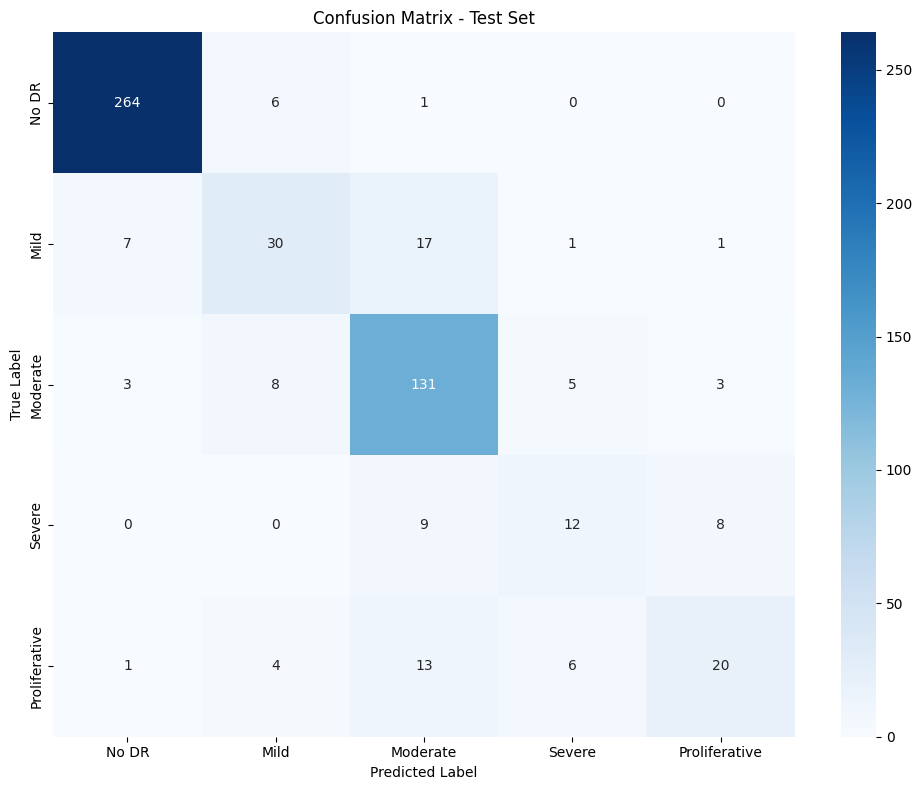


CLASSIFICATION REPORT
               precision    recall  f1-score   support

        No DR       0.96      0.97      0.97       271
         Mild       0.62      0.54      0.58        56
     Moderate       0.77      0.87      0.82       150
       Severe       0.50      0.41      0.45        29
Proliferative       0.62      0.45      0.53        44

     accuracy                           0.83       550
    macro avg       0.70      0.65      0.67       550
 weighted avg       0.82      0.83      0.82       550



In [ ]:
print("\n" + "="*80)
print("FINAL EVALUATION ON TEST SET")
print("="*80)

test_metrics = validate(model, test_loader, loss_fn, device, CONFIG)

print(f"\nTest Results:")
print(f"Loss: {test_metrics['loss']:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"F1 Score (Macro): {test_metrics['f1_macro']:.4f}")
print(f"Quadratic Weighted Kappa: {test_metrics['kappa']:.4f}")

# Get predictions for confusion matrix
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative'],
            yticklabels=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f"{CONFIG['MODELS_DIR']}/confusion_matrix.png", dpi=150)
plt.show()

# Classification Report
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print(classification_report(
    all_labels, all_preds,
    target_names=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
))


In [ ]:
def predict_single_image(model, image_path, transform, device, config):
    """Predict DR severity for a single image"""
    model.eval()

    # Load and preprocess image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Apply transforms
    augmented = transform(image=image)
    image_tensor = augmented['image'].unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        if config['USE_AMP']:
            with autocast():
                output = model(image_tensor)
        else:
            output = model(image_tensor)

        probabilities = F.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][predicted_class].item()

    class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']

    return {
        'predicted_class': predicted_class,
        'class_name': class_names[predicted_class],
        'confidence': confidence,
        'all_probabilities': probabilities[0].cpu().numpy()
    }

# Example usage
val_transform = get_val_transforms(CONFIG)

# Test on a sample image from test set
sample_image_path = test_df.iloc[0]['image_path']
result = predict_single_image(model, sample_image_path, val_transform, device, CONFIG)

print("\n" + "="*80)
print("SAMPLE PREDICTION")
print("="*80)
print(f"Image: {sample_image_path}")
print(f"Predicted Class: {result['class_name']}")
print(f"Confidence: {result['confidence']:.4f}")
print("\nAll Class Probabilities:")
class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
for name, prob in zip(class_names, result['all_probabilities']):
    print(f"  {name}: {prob:.4f}")



SAMPLE PREDICTION
Image: /content/drive/MyDrive/archive/colored_images/Moderate/89ee1fa16f90.png
Predicted Class: Moderate
Confidence: 0.5298

All Class Probabilities:
  No DR: 0.0289
  Mild: 0.2627
  Moderate: 0.5298
  Severe: 0.1115
  Proliferative DR: 0.0674


In [ ]:
# Save complete model
torch.save({
    'model_state_dict': model.state_dict(),
    'config': CONFIG,
    'test_metrics': test_metrics
}, f"{CONFIG['MODELS_DIR']}/final_dr_model.pth")

print("\n✅ Final model saved successfully!")
print(f"Model location: {CONFIG['MODELS_DIR']}/final_dr_model.pth")



✅ Final model saved successfully!
Model location: /content/drive/MyDrive/models/final_dr_model.pth


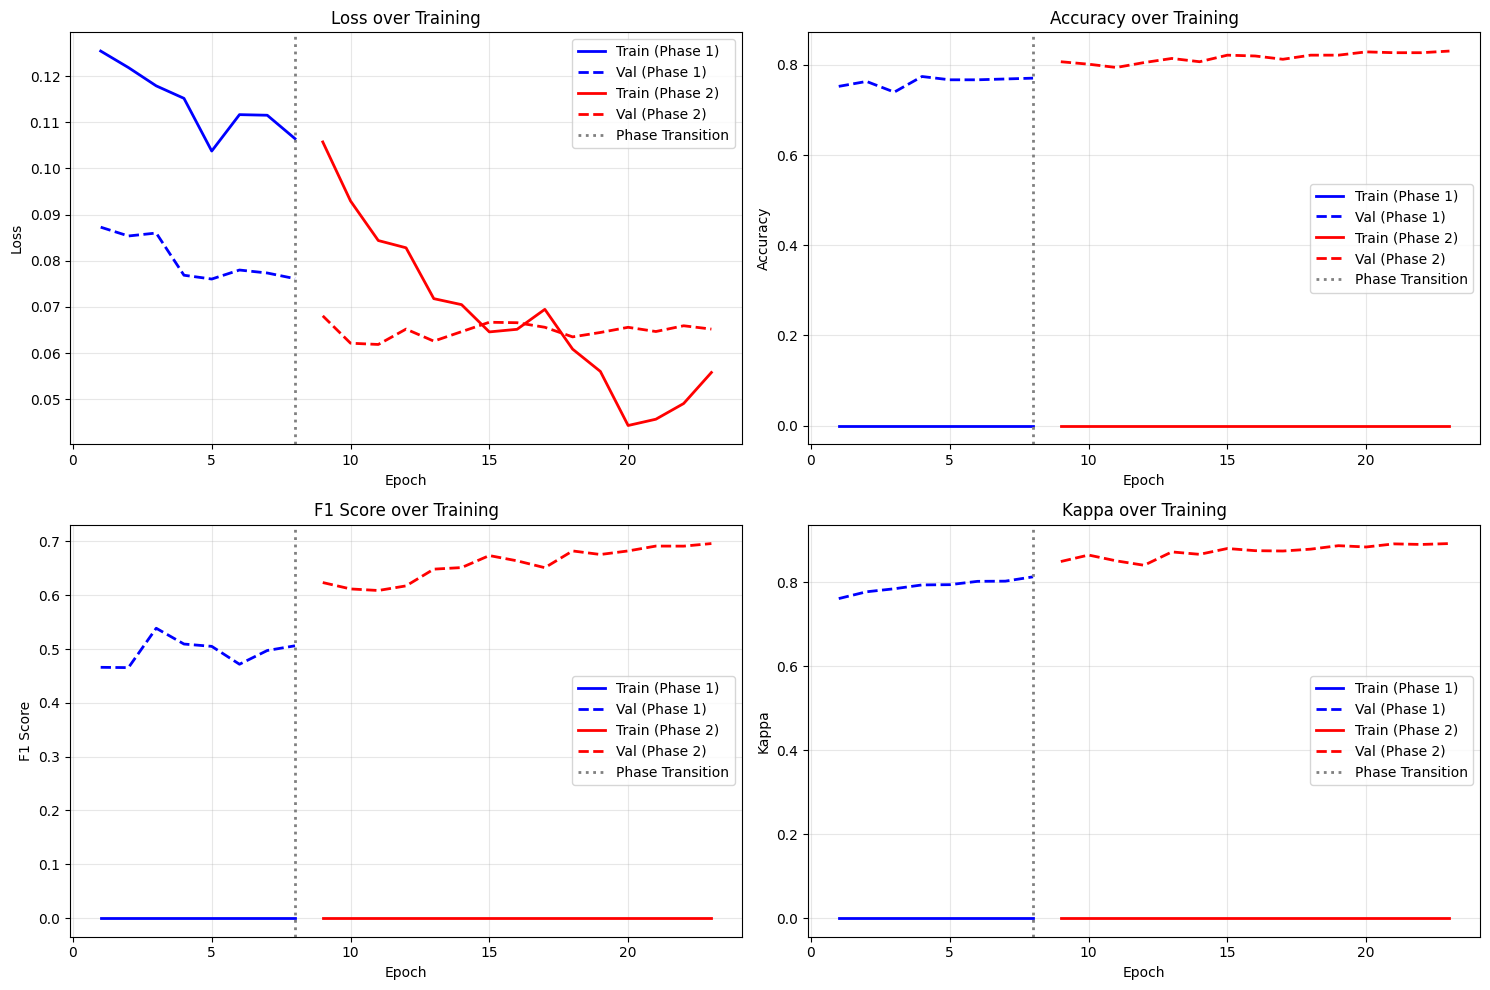

✅ Training history plotted!


In [ ]:
def plot_training_history(history_phase1, history_phase2, save_path):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    metrics = ['loss', 'acc', 'f1', 'kappa']
    titles = ['Loss', 'Accuracy', 'F1 Score', 'Kappa']

    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx // 2, idx % 2]

        # Phase 1
        train_key = f'train_{metric}'
        val_key = f'val_{metric}'

        phase1_epochs = len(history_phase1[train_key])
        phase2_epochs = len(history_phase2[train_key])

        x1 = range(1, phase1_epochs + 1)
        x2 = range(phase1_epochs + 1, phase1_epochs + phase2_epochs + 1)

        ax.plot(x1, history_phase1[train_key], 'b-', label='Train (Phase 1)', linewidth=2)
        ax.plot(x1, history_phase1[val_key], 'b--', label='Val (Phase 1)', linewidth=2)
        ax.plot(x2, history_phase2[train_key], 'r-', label='Train (Phase 2)', linewidth=2)
        ax.plot(x2, history_phase2[val_key], 'r--', label='Val (Phase 2)', linewidth=2)

        ax.axvline(x=phase1_epochs, color='gray', linestyle=':', linewidth=2, label='Phase Transition')

        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.set_title(f'{title} over Training')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

plot_training_history(history_phase1, history_phase2, f"{CONFIG['MODELS_DIR']}/training_history.png")
print("✅ Training history plotted!")
